In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


import torch
from torch import optim
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm

# !pip install torchvision
import torchvision

import torch.nn.functional as F
import torchvision.datasets as datasets
import torchvision.transforms as transforms

# !pip install torchmetrics
import torchmetrics

In [87]:
import random
torch.manual_seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [89]:
from torchvision.datasets import ImageFolder

In [99]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images to 224x224
    transforms.ToTensor(),         # Convert to PyTorch Tensor (scales to [0, 1])
    transforms.Normalize((0),(1)) # Normalize pixel values
])
data_train = ImageFolder(root=r'./train/', transform=transform)
data_validation = ImageFolder(root=r'./validation/', transform=transform)
data_test = ImageFolder(root=r'./test/', transform=transform)

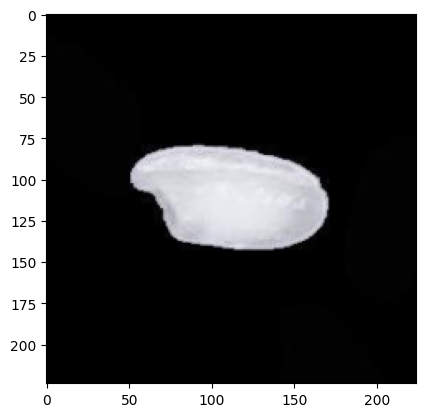

In [101]:
plt.imshow(np.transpose(data_train[0][0].cpu().numpy(), (1,2,0)))

In [103]:
data_test

Dataset ImageFolder
    Number of datapoints: 200
    Root location: ./test/
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=0, std=1)
           )

In [105]:
data_train

Dataset ImageFolder
    Number of datapoints: 74600
    Root location: ./train/
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=0, std=1)
           )

In [109]:
batch_size = 32
train_loader = DataLoader(data_train, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(data_test,  batch_size=batch_size, shuffle=False)
validation_loader  = DataLoader(data_validation,  batch_size=batch_size, shuffle=False)

In [111]:
image, label = data_train[0]
image.size()

torch.Size([3, 224, 224])

In [113]:
for images, labels in train_loader:
    break
images.shape, labels.shape

(torch.Size([32, 3, 224, 224]), torch.Size([32]))

In [115]:
model = nn.Sequential()
first_conv_layer = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=4, padding=1, stride=2)
model.add_module("Conv1", first_conv_layer)
first_max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
model.add_module("MaxPool1", first_max_pool)
second_conv_layer = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1, stride=2)
model.add_module("Conv2", second_conv_layer)
second_max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
model.add_module("MaxPool2", second_max_pool)
output = model(data_train[0][0])
output.size()

torch.Size([64, 14, 14])

In [117]:
input_dim  = 3*224*224
class CNN(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(CNN, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=4, padding=1, stride=2), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1, stride=2), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), nn.BatchNorm2d(64),
            nn.Flatten(),
            nn.Linear(64*14*14, 128), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 5) #5 num of classes
        )
    def forward(self, x):
        logits = self.net(x)
        return logits
model = CNN(3, 5).to(device)
print(model)

CNN(
  (net): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): Flatten(start_dim=1, end_dim=-1)
    (9): Linear(in_features=12544, out_features=128, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.5, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): ReLU()
    (14): Linear(in_features=64, out_features=5, bias=True)
  )
)


In [119]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [121]:
patience = 2   # скільки епох чекати
best_val_loss = float('inf')
epochs_no_improve = 0
n_epochs = 50
best_model_path = "best_model.pth"
train_loss_history = []
val_loss_history = []
for epoch in range(n_epochs):

    # --- train ---
    model.train()
    train_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # --- validation ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            val_loss += loss.item()
    val_loss /= len(test_loader)

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)
    print(f"[{epoch+1:02d}] train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    # --- check improvement ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_model_path)   #save best model
        print("Saved best model")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping epoch: ", epoch)
            break

[01] train_loss=0.1330 | val_loss=0.0303
Saved best model
[02] train_loss=0.0593 | val_loss=0.0157
Saved best model
[03] train_loss=0.0422 | val_loss=0.0327
[04] train_loss=0.0371 | val_loss=0.0071
Saved best model
[05] train_loss=0.0299 | val_loss=0.0341
[06] train_loss=0.0285 | val_loss=0.0030
Saved best model
[07] train_loss=0.0279 | val_loss=0.0003
Saved best model
[08] train_loss=0.0275 | val_loss=0.0082
[09] train_loss=0.0257 | val_loss=0.0064
Early stopping epoch:  8


In [123]:
best_model = CNN(3, 5).to(device)
best_model.load_state_dict(torch.load(best_model_path, map_location=device))
best_model.eval()
print("Best model loaded")

Best model loaded


In [125]:
correct, total = 0, 0
with torch.no_grad():
    for x, y in test_loader:     #  batch of images and labels
        x, y = x.to(device), y.to(device)
        preds = best_model(x).argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

print(f"Test accuracy: {100 * correct / total:.2f}%")

Test accuracy: 100.00%


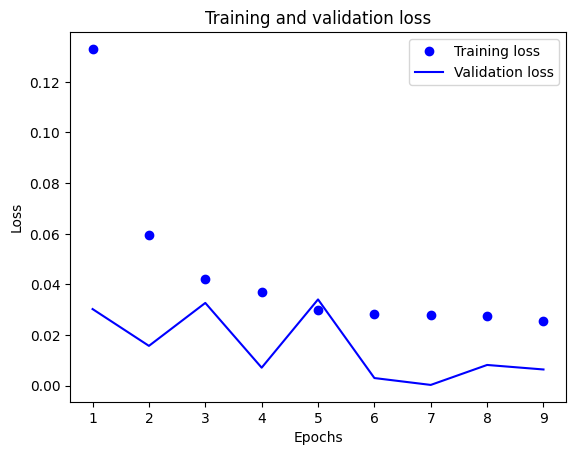

In [127]:
import matplotlib.pyplot as plt
epochs = range(1, len(train_loss_history) + 1)
plt.plot(epochs, train_loss_history, "bo", label="Training loss")
plt.plot(epochs, val_loss_history, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [129]:
from torchvision.models import resnet50, ResNet50_Weights
resnet = resnet50(pretrained=True)
num_ftrs = resnet.fc.in_features
print(num_ftrs)

2048


In [131]:
from torchvision import models
class FinetuneResnet(nn.Module):
    def __init__(self, num_classes):
        super(FinetuneResnet, self).__init__()

        self.model = models.resnet50(pretrained=True)
        self.fc1 = nn.Linear(2048, 2048)
        self.fc2 = nn.Linear(2048, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.model.conv1(x)
        x = self.model.bn1(x)
        x = self.model.relu(x)
        x = self.model.maxpool(x)

        x = self.model.layer1(x)
        x = self.model.layer2(x)
        x = self.model.layer3(x)
        x = self.model.layer4(x)
        x = self.model.avgpool(x)

        x = x.view(x.size(0), -1)
        x = nn.functional.relu(self.fc1(x))
        x = self.dropout(x)
        x = nn.functional.softmax(self.fc2(x), dim=1)

        return x

In [133]:
criterion = nn.NLLLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [135]:
model = FinetuneResnet(5)

In [137]:
patience = 2   # скільки епох чекати
best_val_loss = float('inf')
epochs_no_improve = 0
n_epochs = 50
best_model_path = "best_model.pth"
train_loss_history = []
val_loss_history = []
for epoch in range(n_epochs):

    # --- train ---
    model.train()
    train_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # --- validation ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            val_loss += loss.item()
    val_loss /= len(test_loader)

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)
    print(f"[{epoch+1:02d}] train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    # --- check improvement ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_model_path)   #save best model
        print("Saved best model")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping epoch: ", epoch)
            break

[01] train_loss=-0.2021 | val_loss=-0.2005
Saved best model
[02] train_loss=-0.2023 | val_loss=-0.2006
Saved best model
[03] train_loss=-0.2023 | val_loss=-0.2006
[04] train_loss=-0.2022 | val_loss=-0.2006
Saved best model
[05] train_loss=-0.2022 | val_loss=-0.2005
[06] train_loss=-0.2023 | val_loss=-0.2008
Saved best model
[07] train_loss=-0.2022 | val_loss=-0.2008
Saved best model
[08] train_loss=-0.2023 | val_loss=-0.2005
[09] train_loss=-0.2022 | val_loss=-0.2008
Early stopping epoch:  8


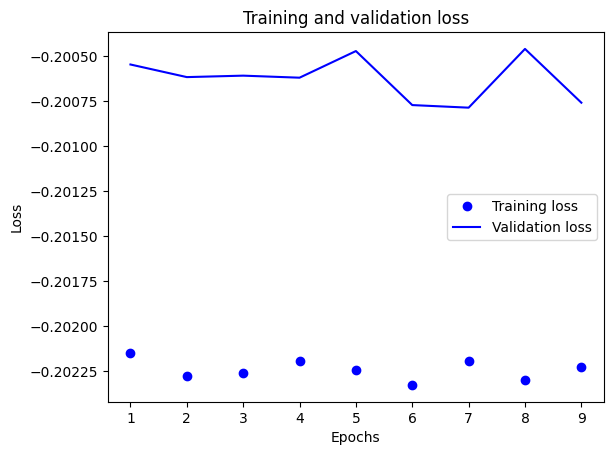

In [139]:
import matplotlib.pyplot as plt
epochs = range(1, len(train_loss_history) + 1)
plt.plot(epochs, train_loss_history, "bo", label="Training loss")
plt.plot(epochs, val_loss_history, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [141]:
correct, total = 0, 0
with torch.no_grad():
    for x, y in test_loader:     #  batch of images and labels
        x, y = x.to(device), y.to(device)
        preds = best_model(x).argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

print(f"Test accuracy: {100 * correct / total:.2f}%")

Test accuracy: 100.00%
